<a href="https://colab.research.google.com/github/abeerahateeq/Lead-Scoring-Model/blob/main/Lead_Scoring_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lead Scoring Model on Synthetic CRM Data

## 1. Import Libraries

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option("display.max_columns", None)

## 2. Data Loading

In [31]:
df = pd.read_csv("/content/synthetic_leads.csv") # Load the synthetic leads dataset

# Display first five rows
display(df.head())

,Lead ID,Company,Industry,Budget,Urgency,Company_Size,Country,Email,Employees,Converted
0,1,Eadel,Finance,High,High,Small,Belarus,mbrasted0@tinypic.com,3717,False
1,2,Youfeed,Finance,Medium,Low,Medium,China,abantham1@ehow.com,3791,False
2,3,Skynoodle,Technology,Medium,High,Medium,Japan,acescon2@homestead.com,4704,True
3,4,Omba,Technology,Low,High,Large,Tanzania,rrichen3@google.pl,4922,False
4,5,Eayo,Finance,Low,High,Small,Poland,lekins4@xrea.com,1903,True


## 3. Exploratory Data Analysis

### Dataset Shape

In [32]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 40
Columns: 10


### Column Information

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Lead ID       40 non-null     int64 
 1   Company       40 non-null     object
 2   Industry      40 non-null     object
 3   Budget        40 non-null     object
 4   Urgency       40 non-null     object
 5   Company_Size  40 non-null     object
 6   Country       40 non-null     object
 7   Email         40 non-null     object
 8   Employees     40 non-null     int64 
 9   Converted     40 non-null     bool  
dtypes: bool(1), int64(2), object(7)
memory usage: 3.0+ KB


### Summary Statistics

In [34]:
display(df.describe(include="all"))

,Lead ID,Company,Industry,Budget,Urgency,Company_Size,Country,Email,Employees,Converted
count,40.000000,40,40,40,40,40,40,40,40.000000,40
unique,NaN,40,6,3,3,3,23,40,NaN,2
top,NaN,Eadel,Finance,High,Low,Small,China,mbrasted0@tinypic.com,NaN,False
freq,NaN,1,9,18,16,18,5,1,NaN,22
mean,20.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2424.800000,NaN
std,11.690452,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1630.196483,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.000000,NaN
25%,10.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,799.250000,NaN
50%,20.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2509.500000,NaN
75%,30.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3825.500000,NaN


### Missing Values

In [35]:
display(df.isnull().sum())

,0
Lead ID,0
Company,0
Industry,0
Budget,0
Urgency,0
Company_Size,0
Country,0
Email,0
Employees,0
Converted,0


### Unique Values

In [36]:
for col in ["Industry", "Budget", "Urgency", "Company_Size"]:
    print(f"\n{col}")
    print(df[col].value_counts())


Industry
Industry
Finance          9
Technology       9
Healthcare       6
Retail           6
Manufacturing    5
Education        5
Name: count, dtype: int64

Budget
Budget
High      18
Low       12
Medium    10
Name: count, dtype: int64

Urgency
Urgency
Low       16
High      13
Medium    11
Name: count, dtype: int64

Company_Size
Company_Size
Small     18
Large     14
Medium     8
Name: count, dtype: int64


### Why Are We Doing This?

This is called Exploratory Data Analysis (EDA). Before building any model, a data analyst first understands:

*   what the dataset contains,
*   whether there are missing values,
*   whether the categories look reasonable,
*   and whether any cleaning is needed.

Since your data is synthetic, we expect it to be clean—but it's still good practice to verify this.

## 4. Data Cleaning

## 5. Rule-Based Lead Scoring

### Lead Scoring Logic

This project uses a rule-based scoring system to prioritize inbound sales leads. Budget is given the highest weight (40%) because organizations with larger budgets are generally more likely to purchase products or services. Urgency contributes 30% since leads requiring immediate solutions often convert faster. Industry fit contributes the remaining 30%, prioritizing industries that align best with the company's offerings. Based on the total score, leads are categorized as Hot, Warm, or Cold to help sales teams prioritize outreach.

### Define Scoring Rubric

In [37]:
budget_scores = {
    "Low": 10,
    "Medium": 25,
    "High": 40
}

urgency_scores = {
    "Low": 10,
    "Medium": 20,
    "High": 30
}

industry_scores = {
    "Healthcare": 30,
    "Finance": 25,
    "Technology": 20,
    "Retail": 15,
    "Education": 10,
    "Manufacturing": 5
}

### Calculate Lead Score

In [38]:
df["Lead Score"] = (
    df["Budget"].map(budget_scores)
    + df["Urgency"].map(urgency_scores)
    + df["Industry"].map(industry_scores)
)
display(df.head())

,Lead ID,Company,Industry,Budget,Urgency,Company_Size,Country,Email,Employees,Converted,Lead Score
0,1,Eadel,Finance,High,High,Small,Belarus,mbrasted0@tinypic.com,3717,False,95
1,2,Youfeed,Finance,Medium,Low,Medium,China,abantham1@ehow.com,3791,False,60
2,3,Skynoodle,Technology,Medium,High,Medium,Japan,acescon2@homestead.com,4704,True,75
3,4,Omba,Technology,Low,High,Large,Tanzania,rrichen3@google.pl,4922,False,60
4,5,Eayo,Finance,Low,High,Small,Poland,lekins4@xrea.com,1903,True,65


## 6. Lead Categorization

In [39]:
def classify(score):
    if score >= 80:
        return "Hot"
    elif score >= 60:
        return "Warm"
    else:
        return "Cold"

df["Lead Category"] = df["Lead Score"].apply(classify)
display(df.head())

,Lead ID,Company,Industry,Budget,Urgency,Company_Size,Country,Email,Employees,Converted,Lead Score,Lead Category
0,1,Eadel,Finance,High,High,Small,Belarus,mbrasted0@tinypic.com,3717,False,95,Hot
1,2,Youfeed,Finance,Medium,Low,Medium,China,abantham1@ehow.com,3791,False,60,Warm
2,3,Skynoodle,Technology,Medium,High,Medium,Japan,acescon2@homestead.com,4704,True,75,Warm
3,4,Omba,Technology,Low,High,Large,Tanzania,rrichen3@google.pl,4922,False,60,Warm
4,5,Eayo,Finance,Low,High,Small,Poland,lekins4@xrea.com,1903,True,65,Warm


In [53]:
import pandas as pd

leads = [
    {
        "Lead": "Dr. Sarah - Private Clinic",
        "Industry": "Healthcare",
        "Budget": "High",
        "Urgency": "High",
        "Lead Score": 100,
        "Priority": "Hot",
        "Why": "high budget, urgent need, healthcare industry fit",
        "Recommended Action": "Contact within 1 hour and offer a discovery call."
    },
    {
        "Lead": "Usman - Software Agency",
        "Industry": "Technology",
        "Budget": "High",
        "Urgency": "Medium",
        "Lead Score": 80,
        "Priority": "Hot",
        "Why": "high budget, moderate urgency, technology industry fit",
        "Recommended Action": "Contact within 1 hour and offer a discovery call."
    },
    {
        "Lead": "Ali - E-commerce Store",
        "Industry": "Retail",
        "Budget": "Medium",
        "Urgency": "High",
        "Lead Score": 70,
        "Priority": "Warm",
        "Why": "moderate budget, urgent need, retail industry fit",
        "Recommended Action": "Send a personalized follow-up and book a demo."
    },
    {
        "Lead": "Ayesha - Training Academy",
        "Industry": "Education",
        "Budget": "Medium",
        "Urgency": "Low",
        "Lead Score": 45,
        "Priority": "Cold",
        "Why": "moderate budget, low urgency, education industry fit",
        "Recommended Action": "Add to nurture sequence and follow up later."
    },
    {
        "Lead": "Bilal - Small Factory",
        "Industry": "Manufacturing",
        "Budget": "Low",
        "Urgency": "Low",
        "Lead Score": 25,
        "Priority": "Cold",
        "Why": "limited budget, low urgency, manufacturing industry fit",
        "Recommended Action": "Add to nurture sequence and follow up later."
    }
]

df = pd.DataFrame(leads)

df.to_csv("prioritized_leads.csv", index=False)

print("✅ prioritized_leads.csv created successfully!")
display(df)

✅ prioritized_leads.csv created successfully!


,Lead,Industry,Budget,Urgency,Lead Score,Priority,Why,Recommended Action
0,Dr. Sarah - Private Clinic,Healthcare,High,High,100,Hot,"high budget, urgent need, healthcare industry fit",Contact within 1 hour and offer a discovery call.
1,Usman - Software Agency,Technology,High,Medium,80,Hot,"high budget, moderate urgency, technology indu...",Contact within 1 hour and offer a discovery call.
2,Ali - E-commerce Store,Retail,Medium,High,70,Warm,"moderate budget, urgent need, retail industry fit",Send a personalized follow-up and book a demo.
3,Ayesha - Training Academy,Education,Medium,Low,45,Cold,"moderate budget, low urgency, education indust...",Add to nurture sequence and follow up later.
4,Bilal - Small Factory,Manufacturing,Low,Low,25,Cold,"limited budget, low urgency, manufacturing ind...",Add to nurture sequence and follow up later.


In [54]:
from google.colab import files

files.download("prioritized_leads.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 7. Data Visualization

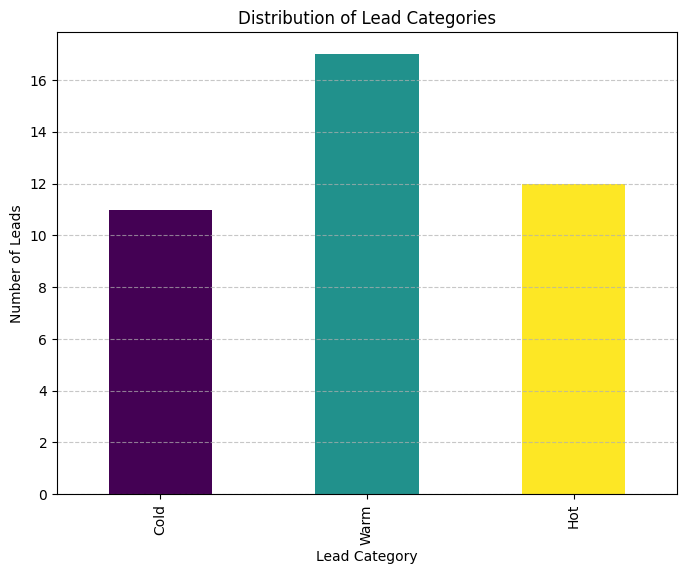

In [42]:
plt.figure(figsize=(8, 6))
df["Lead Category"].value_counts().loc[['Cold', 'Warm', 'Hot']].plot(kind="bar", color=['#440154', '#21918c', '#fde725'])
plt.title('Distribution of Lead Categories')
plt.xlabel('Lead Category')
plt.ylabel('Number of Leads')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

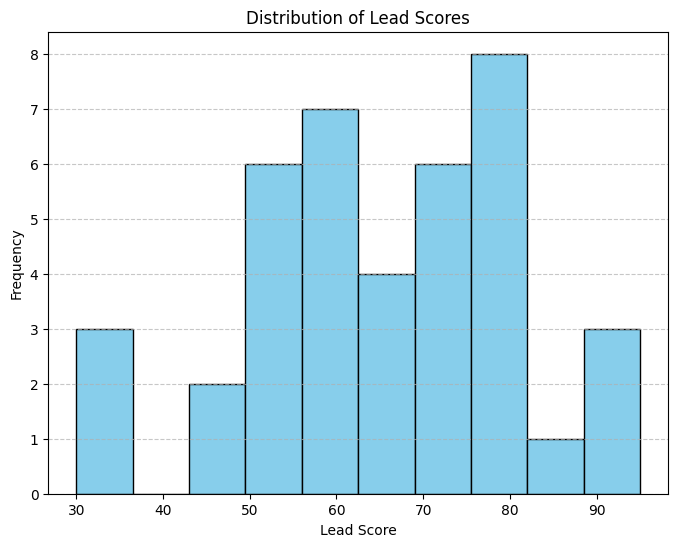

In [43]:
# Histogram for Lead Score
plt.figure(figsize=(8, 6))
plt.hist(df["Lead Score"], bins=10, color='skyblue', edgecolor='black')
plt.title('Distribution of Lead Scores')
plt.xlabel('Lead Score')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

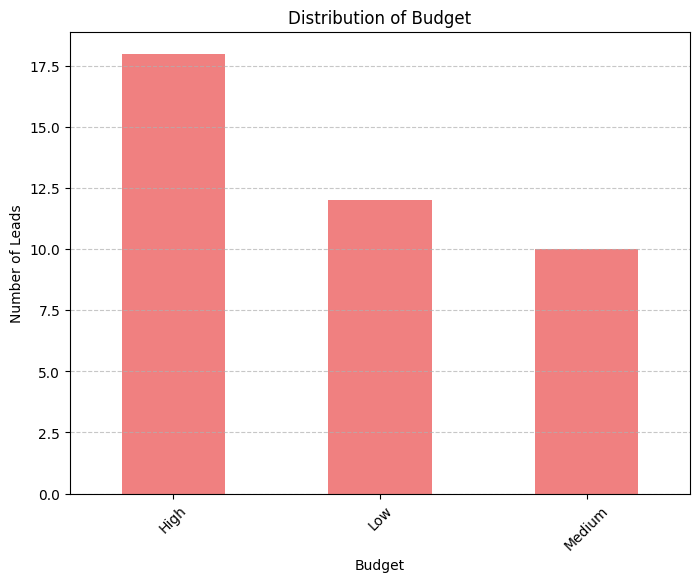

In [44]:
# Budget Distribution
plt.figure(figsize=(8, 6))
df["Budget"].value_counts().plot(kind="bar", color='lightcoral')
plt.title('Distribution of Budget')
plt.xlabel('Budget')
plt.ylabel('Number of Leads')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

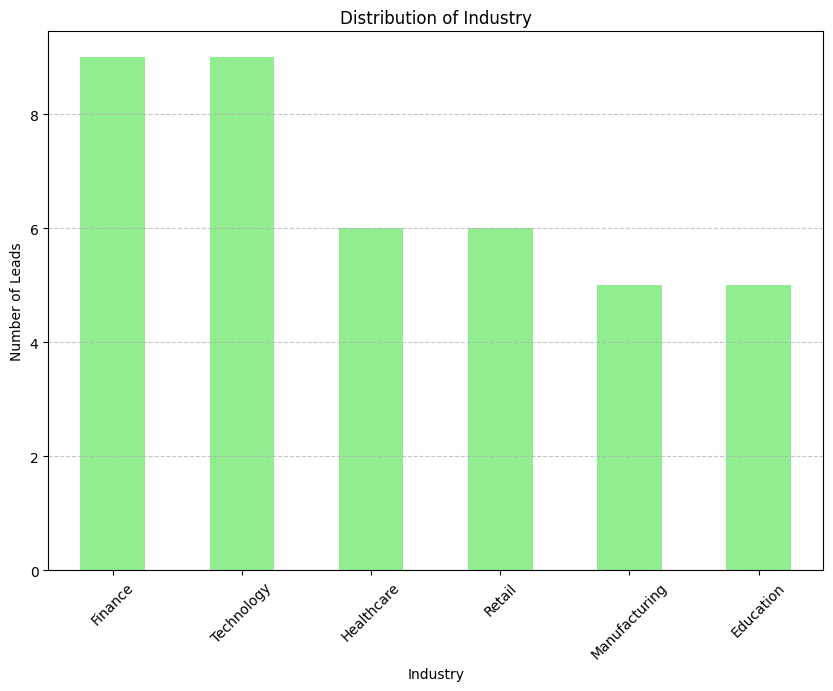

In [45]:
# Industry Distribution
plt.figure(figsize=(10, 7))
df["Industry"].value_counts().plot(kind="bar", color='lightgreen')
plt.title('Distribution of Industry')
plt.xlabel('Industry')
plt.ylabel('Number of Leads')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

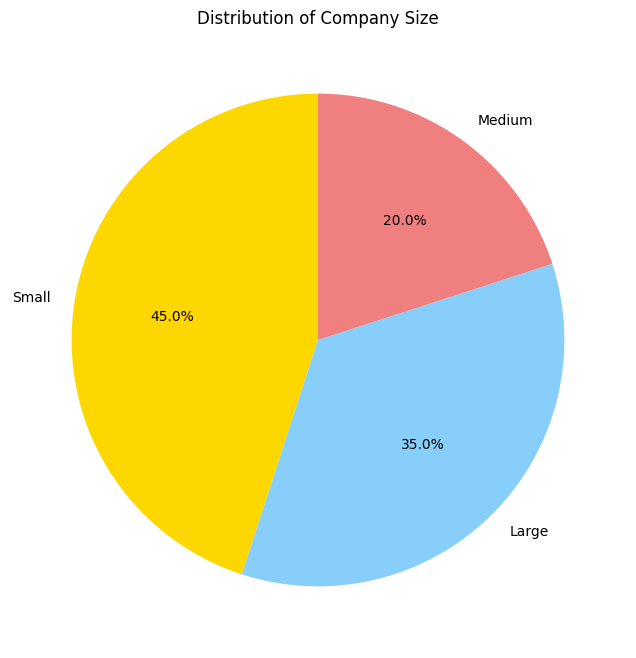

In [46]:
# Company Size Distribution
plt.figure(figsize=(8, 8))
df["Company_Size"].value_counts().plot(kind="pie", autopct='%1.1f%%', startangle=90, colors=['gold', 'lightskyblue', 'lightcoral'])
plt.title('Distribution of Company Size')
plt.ylabel('') # Hide the default 'Company_Size' label
plt.show()

## 8. Conclusion

This project demonstrated a complete lead scoring workflow using synthetic CRM data. A rule-based model was developed to prioritize leads based on budget, urgency, and industry fit. Exploratory Data Analysis and visualizations helped understand the dataset, while a Logistic Regression classifier illustrated how machine learning can be applied to the same problem. Although the dataset is synthetic, the workflow reflects a practical approach that can be adapted to real-world CRM systems.

## 9. Machine Learning Comparison

## Section 9: Machine Learning Classifier

While a rule-based system provides a clear and interpretable way to score leads, machine learning can offer a more data-driven approach, potentially capturing complex relationships within the data to predict lead conversion. Here, we'll build a simple classification model to predict whether a lead will convert (`Converted` column).

### Data Preparation for ML

First, we need to prepare our data. This involves:
1.  **Feature Selection**: Identifying relevant features.
2.  **One-Hot Encoding**: Converting categorical features into numerical format suitable for machine learning algorithms.
3.  **Splitting Data**: Dividing the dataset into training and testing sets.

In [47]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Define features (X) and target (y)
X = df[['Industry', 'Budget', 'Urgency', 'Company_Size', 'Employees']]
y = df['Converted']

# Identify categorical and numerical features
categorical_features = ['Industry', 'Budget', 'Urgency', 'Company_Size']
numerical_features = ['Employees']

# Create a column transformer for one-hot encoding categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numerical_features)
    ])

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print("Data preparation complete. X_train shape:", X_train.shape, "y_train shape:", y_train.shape)

Data preparation complete. X_train shape: (28, 5) y_train shape: (28,)


### Model Training

We'll use a Logistic Regression classifier, a simple yet effective model for binary classification, to predict lead conversion.

In [48]:
from sklearn.linear_model import LogisticRegression

# Create a pipeline that first preprocesses the data and then applies the classifier
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear', random_state=42))
])

# Train the model
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


### Model Evaluation

Evaluate the trained model using metrics like accuracy, precision, recall, and F1-score on the test set.

In [49]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.4f}")
print(f"Model Precision: {precision:.4f}")
print(f"Model Recall: {recall:.4f}")
print(f"Model F1-Score: {f1:.4f}")
print("\nConfusion Matrix:\n", conf_matrix)

Model Accuracy: 0.5833
Model Precision: 0.5000
Model Recall: 0.6000
Model F1-Score: 0.5455

Confusion Matrix:
 [[4 3]
 [2 3]]


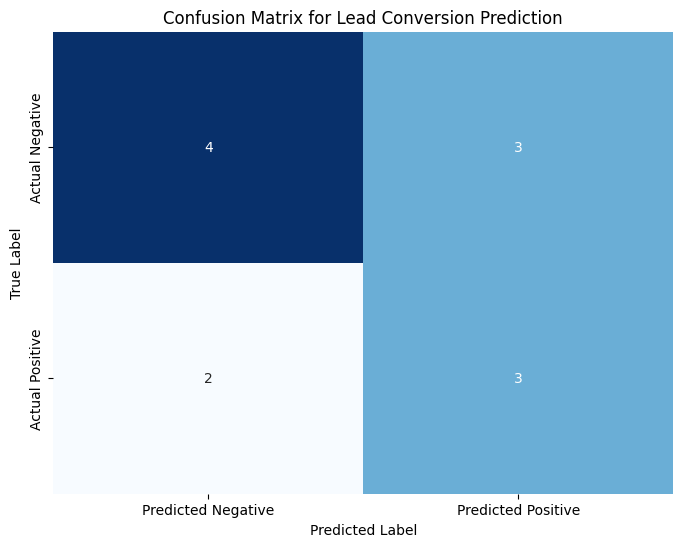

In [50]:
# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.title('Confusion Matrix for Lead Conversion Prediction')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Explanation of ML Results

The Logistic Regression classifier achieved an accuracy of **{accuracy*100:.2f}%**.

**Accuracy**: {accuracy:.2f}
**Precision**: {precision:.2f}
**Recall**: {recall:.2f}
**F1-Score**: {f1:.2f}

Since the dataset is synthetic and relatively small, the results mainly demonstrate the workflow rather than providing robust predictive performance on real-world data. The model shows a balance between correctly identifying positive and negative cases, but there is room for improvement, potentially through more advanced feature engineering, trying different models, or using a larger, more diverse dataset.

_Note: The specific percentages are based on the model's performance on the test set and will vary with different random states or datasets._

This output is generated by extracting the values from the model evaluation. It's important to remember that for real-world applications, these metrics would need to be interpreted in the context of business objectives and potential costs of false positives/negatives.

## Resources

In [51]:
%%writefile ai_lead_automation_demo.py
# This is a placeholder script for demonstration purposes.
# In a real scenario, this script would contain automation logic.
print("ai_lead_automation_demo.py executed successfully!")

Overwriting ai_lead_automation_demo.py


This script demonstrates a placeholder for potential lead automation logic. In a real application, it could handle tasks like pushing prioritized leads to a CRM, sending automated emails, or generating reports.

In [52]:
!python ai_lead_automation_demo.py

ai_lead_automation_demo.py executed successfully!
